---
title: Optimizing for Site Cost
toc: true
execute: 
  enabled: true
image: image.png
---

As well as demand, equity, and other custom datasets, lokigi lets you attach a fixed **cost** to each candidate site -- for example, the capital cost of building a new facility, or its ongoing running cost.

Pass a `cost_col` to `add_sites()` to register it. The **total cost of whichever sites end up selected is always calculated and reported** in `solutions_df` as `total_cost`, regardless of whether you use it for anything else.

Cost only ever changes *which* sites get selected if you explicitly ask lokigi to weight by it, using the same `weights` dictionary already used for demand and equity in [Multiobjective Optimisation with Weights](../multiobjective_optimisation_weights/index.ipynb), or if you are looking at multiobjective optimisation with pareto fronts, as in [Multiobjective optimisation with pareto fronts](../multiobjective_optimisation_pareto/index.ipynb).

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_cdcs_with_costs.csv",
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing",
    cost_col="Build_Cost_GBP_Thousands",
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="Total",
    location_id_col="LSOA 2021 Name"
    )

problem.add_equity_data(
    "../../../sample_data/devon_imd_2025_2021_LSOAs.csv",
    equity_col="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA",
    common_col="LSOA name (2021)",
    label="IMD Decile (1 = most deprived)"
    )

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


## A quick look at site costs

`devon_cdcs_with_costs.csv` is a copy of the `devon_cdcs.csv` sample data used elsewhere in these examples, with an extra `Build_Cost_GBP_Thousands` column added.

The four `Existing` sites (which `required_sites_col` forces into every solution) have a cost of `0` -- they're already open, so there's no new build cost for including them. The fourteen candidate sites range from roughly £240k to £620k to build.

In [2]:
problem.show_sites()[["Facility_Name", "Existing", "Build_Cost_GBP_Thousands"]]

,Facility_Name,Existing,Build_Cost_GBP_Thousands
0,Bideford Community Hospital,Yes,0
1,NHS Nightingale Exeter,Yes,0
2,"Colin Campbell Court, Plymouth",Yes,0
3,Torbay & South Devon Community Diagnostic Centre,Yes,0
4,Tiverton - Lowman Way,No,450
5,Okehampton - Exeter Road Industrial Estate,No,260
6,Crediton - Lords Meadow,No,300
7,South Molton - Pathfields,No,280
8,Newton Abbott - Market Walk,No,620
9,Bovey Tracey - Blue Waters,No,340


## Solving without weighting cost

By default (or with `weights={"demand": 1.0}`), `total_cost` is still calculated for every candidate solution -- but it has no influence on which one is ranked best. Only travel time (weighted by demand) matters here.

In [3]:
solution_unweighted = problem.solve(p=5, objectives="p_median", threshold_for_coverage=30)
solution_unweighted.show_solutions(n_best=3)[["site_names", "weighted_average", "total_cost"]]

  0%|          | 0/14 [00:00<?, ?it/s]

,site_names,weighted_average,total_cost
0,"[Bideford Community Hospital, NHS Nightingale ...",20.23,510
1,"[Bideford Community Hospital, NHS Nightingale ...",20.43,260
2,"[Bideford Community Hospital, NHS Nightingale ...",20.44,620


The best solution adds **Barnstaple - Archwood Retail Park** to the four existing sites -- purely because it gives the best average travel time. At £510k, it's one of the more expensive candidates, but cost had no say in the decision.

## Weighting by cost

Passing `"cost"` in the `weights` dictionary tells lokigi to take `total_cost` into account when comparing candidate solutions, alongside demand (and equity, if configured). It's blended in using the same combination-level, batch-relative comparison used to rank solutions across every search strategy (`brute-force`, `greedy`, and `grasp`).

:::{.callout-note}
`weights={"cost": ...}` requires `cost_col` to have been passed to `add_sites()` first -- otherwise lokigi raises a clear `KeyError` telling you to add site costs before weighting by them (see [below](#what-if-no-cost-is-provided)).
:::

In [4]:
solution_cost_weighted = problem.solve(
    p=5, objectives="p_median", threshold_for_coverage=30, weights={"demand": 1.0, "cost": 1.0}
    )
solution_cost_weighted.show_solutions(n_best=3)[["site_names", "weighted_average", "total_cost"]]

  0%|          | 0/14 [00:00<?, ?it/s]

,site_names,weighted_average,total_cost
0,"[Bideford Community Hospital, NHS Nightingale ...",20.43,260
1,"[Bideford Community Hospital, NHS Nightingale ...",20.57,340
2,"[Bideford Community Hospital, NHS Nightingale ...",20.23,510


Now **Okehampton - Exeter Road Industrial Estate** is selected instead -- roughly half the build cost of Barnstaple (£260k vs £510k), for a weighted average travel time barely 1% worse (20.43 vs 20.23 minutes). A strong trade in most planning contexts.

## Exploring the cost/travel-time trade-off

Sweeping the balance between `demand` and `cost` shows how the chosen site shifts as cost is given more weight.

In [5]:
import pandas as pd

sweep_rows = []
for cost_weight in [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]:
    result = problem.solve(
        p=5, objectives="p_median", threshold_for_coverage=30, show_progress=False,
        weights={"demand": 1.0 - cost_weight, "cost": cost_weight},
        )
    best = result.show_solutions().iloc[0]
    new_site = [
        site for site in best["site_names"]
        if site not in problem.candidate_sites.loc[
            problem.candidate_sites["Existing"] == "Yes", "Facility_Name"
        ].tolist()
    ]
    sweep_rows.append({
        "cost_weight": cost_weight,
        "new_site": new_site[0],
        "weighted_average": best["weighted_average"],
        "total_cost": best["total_cost"],
        })

pd.DataFrame(sweep_rows)

,cost_weight,new_site,weighted_average,total_cost
0,0.0,Barnstaple - Archwood Retail Park,20.23,510
1,0.2,Barnstaple - Archwood Retail Park,20.23,510
2,0.4,Okehampton - Exeter Road Industrial Estate,20.43,260
3,0.5,Okehampton - Exeter Road Industrial Estate,20.43,260
4,0.6,Okehampton - Exeter Road Industrial Estate,20.43,260
5,0.8,Okehampton - Exeter Road Industrial Estate,20.43,260
6,1.0,Holsworthy - Underlane,20.94,240


Three distinct tiers emerge as the cost weight increases, each cheaper than the last at the expense of a little travel time:

- **Low cost weight (0.0-0.2):** Barnstaple - Archwood Retail Park (£510k, 20.23 min)
- **Balanced (0.4-0.8):** Okehampton - Exeter Road Industrial Estate (£260k, 20.43 min)
- **Cost only (1.0):** Holsworthy - Underlane (£240k, 20.94 min)

:::{.callout-note}
As with other weights, mixing objectives this way can be opaque and have limited effect on the outcome -- as seen above, several weight combinations here produce identical results. For a more transparent way to explore cost/travel-time trade-offs, consider [comparing solutions directly](../comparing_solutions/index.ipynb) or a [pareto-front approach](../multiobjective_optimisation_pareto/index.ipynb) treating cost as a second objective.
:::

## Combining cost with other weights

Cost composes with the rest of the weighting system just like any other key -- here it's blended alongside demand and equity in a single solve.

In [6]:
solution_combined = problem.solve(
    p=5, objectives="p_median", threshold_for_coverage=30,
    weights={"demand": 0.4, "equity": 0.3, "cost": 0.3},
    )
solution_combined.show_solutions(n_best=3)[["site_names", "weighted_average", "total_cost"]]

  0%|          | 0/14 [00:00<?, ?it/s]

,site_names,weighted_average,total_cost
0,"[Bideford Community Hospital, NHS Nightingale ...",20.12,260
1,"[Bideford Community Hospital, NHS Nightingale ...",19.90,510
2,"[Bideford Community Hospital, NHS Nightingale ...",20.21,450


## What if no cost is provided?

`cost_col` is entirely optional. If it's never passed to `add_sites()`, everything works exactly as before: `total_cost` is reported as `NaN` in `solutions_df`, and attempting to weight by `"cost"` raises a clear error rather than silently doing nothing.

In [7]:
problem_no_cost = SiteProblem()

problem_no_cost.add_sites(
    "../../../sample_data/devon_cdcs.csv",
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing",
    )

problem_no_cost.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem_no_cost.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="Total",
    location_id_col="LSOA 2021 Name"
    )

solution_no_cost = problem_no_cost.solve(p=5, objectives="p_median", threshold_for_coverage=30)
solution_no_cost.show_solutions(n_best=3)[["site_names", "weighted_average", "total_cost"]]

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


  0%|          | 0/14 [00:00<?, ?it/s]

,site_names,weighted_average,total_cost
0,"[Bideford Community Hospital, NHS Nightingale ...",20.23,NaN
1,"[Bideford Community Hospital, NHS Nightingale ...",20.43,NaN
2,"[Bideford Community Hospital, NHS Nightingale ...",20.44,NaN


In [8]:
try:
    problem_no_cost.solve(
        p=5, objectives="p_median", threshold_for_coverage=30, weights={"cost": 1.0}
        )
except KeyError as e:
    print(f"KeyError: {e}")

KeyError: "The following weight keys are missing from the problem data: ['cost']"


## Comparing cost via a pareto front

Rather than picking a single cost weight, we can treat `total_cost` as just another metric in a **pareto front**, exactly as in [Multiobjective Optimisation with Pareto Fronts](../multiobjective_optimisation_pareto/index.ipynb). This avoids having to choose an arbitrary weight, and instead surfaces every non-dominated cost/travel-time trade-off at once.

We'll reuse `solution_unweighted` from earlier -- `total_cost` was already calculated for every candidate solution regardless of weighting, so no re-solving is needed.

In [9]:
from lokigi.multiobjective import ParetoMetric

### Cost vs weighted average travel time

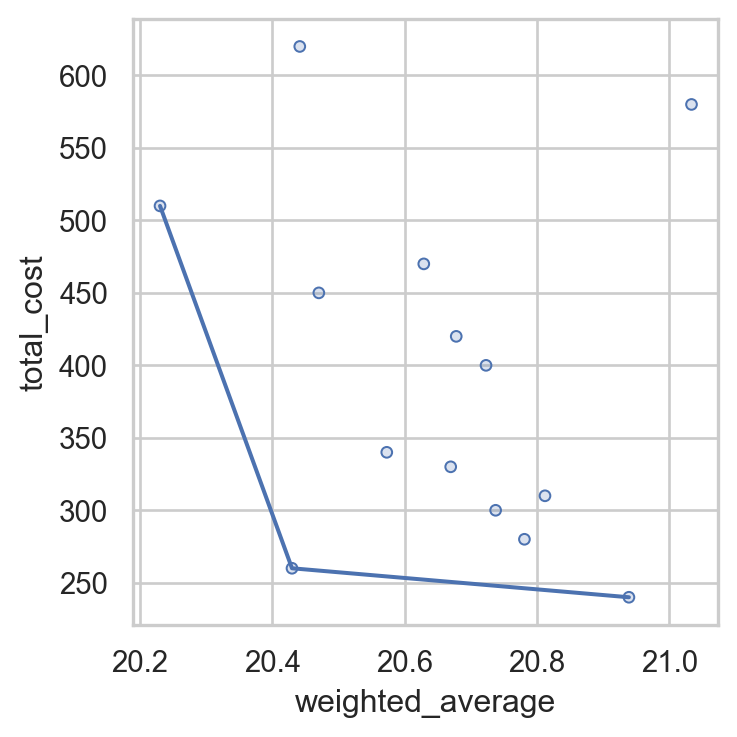

In [10]:
solution_unweighted.plot_simple_pareto_front_pairs(x_axis="weighted_average", y_axis="total_cost")

Three non-dominated solutions make up this front -- the same three tiers found by sweeping the cost weight earlier:

- Weighted average travel time of 20.23 minutes, total cost of £510k
- Weighted average travel time of 20.43 minutes (worse), total cost of £260k (much cheaper)
- Weighted average travel time of 20.94 minutes (worse again), total cost of £240k (cheapest)

Every other candidate solution is dominated -- there's some site on this front that beats it on both cost and travel time.

### Considering cost alongside more metrics

As before, we can use `ParetoMetric` to weigh up cost against more than one other objective at a time -- here, travel time and coverage.

In [11]:
metrics = [
        ParetoMetric(column="weighted_average", direction="lower_better",
                     label="weighted average travel time", unit="minutes"),
        ParetoMetric(column="total_cost", direction="lower_better",
                     label="total build cost", unit="£k"),
        ParetoMetric(column="proportion_within_coverage_threshold", direction="higher_better",
                     label="proportion within coverage threshold"),
        ]

solution_unweighted.compute_pareto_front(metrics=metrics)

solution_unweighted.show_solutions()[[
    "solution_rank", "site_names", "weighted_average", "total_cost",
    "proportion_within_coverage_threshold", "is_pareto_optimal", "dominated_by",
    ]]

,solution_rank,site_names,weighted_average,total_cost,proportion_within_coverage_threshold,is_pareto_optimal,dominated_by
0,1,"[Bideford Community Hospital, NHS Nightingale ...",20.23,510,0.80,True,[]
1,2,"[Bideford Community Hospital, NHS Nightingale ...",20.43,260,0.79,True,[]
2,3,"[Bideford Community Hospital, NHS Nightingale ...",20.44,620,0.79,False,"[1, 2]"
3,4,"[Bideford Community Hospital, NHS Nightingale ...",20.47,450,0.80,True,[]
4,5,"[Bideford Community Hospital, NHS Nightingale ...",20.57,340,0.79,False,[2]
5,6,"[Bideford Community Hospital, NHS Nightingale ...",20.63,470,0.78,False,"[2, 4, 5]"
6,7,"[Bideford Community Hospital, NHS Nightingale ...",20.67,330,0.80,True,[]
7,8,"[Bideford Community Hospital, NHS Nightingale ...",20.68,420,0.79,False,"[2, 5, 7]"
8,9,"[Bideford Community Hospital, NHS Nightingale ...",20.72,400,0.79,False,"[2, 5, 7]"
9,10,"[Bideford Community Hospital, NHS Nightingale ...",20.74,300,0.80,True,[]


Bringing coverage into the picture grows the non-dominated set from three solutions to six -- some of the cheaper options that were dominated on cost/travel-time alone turn out to offer better coverage than their neighbours, so they earn a place back on the front.

`pareto_summary()` returns just these non-dominated solutions, sorted by the first metric in the list.

In [12]:
solution_unweighted.pareto_summary()

,solution_rank,weighted_average,total_cost,proportion_within_coverage_threshold
0,1,20.230707,510,0.801097
1,2,20.429983,260,0.792867
2,4,20.470531,450,0.798354
3,7,20.669638,330,0.795610
4,10,20.737475,300,0.795610
5,13,20.938731,240,0.780521


We can also visualise every non-dominated solution across all three metrics at once with `plot_pareto_summary()` -- as before, values further up each axis are always better, cost included.

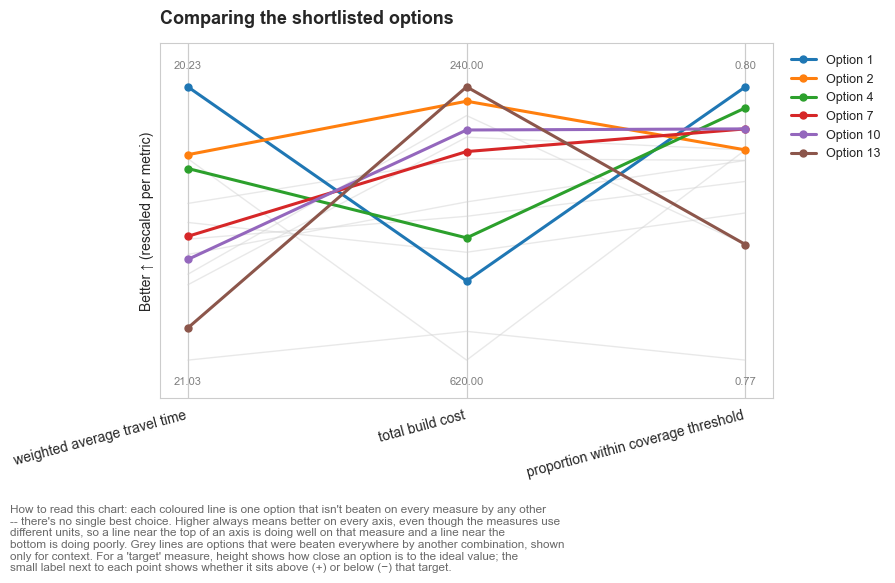

In [13]:
solution_unweighted.plot_pareto_summary(width_multiplier=3);

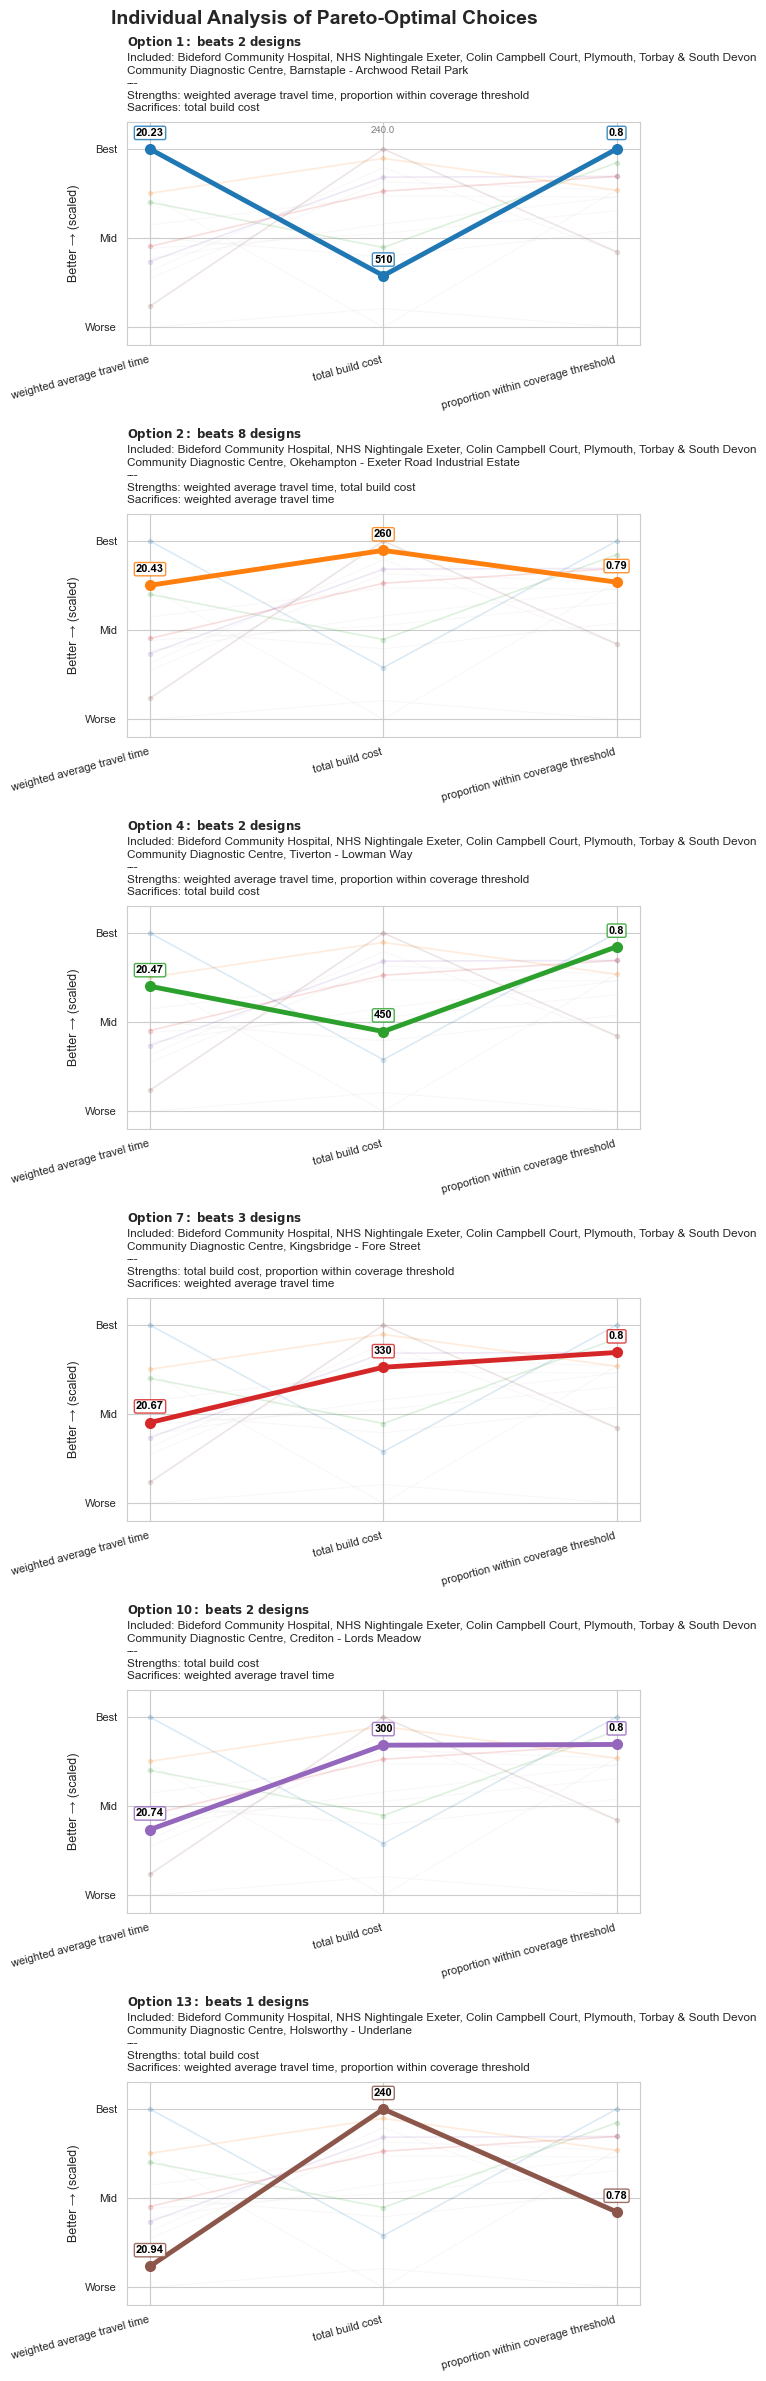

In [14]:
solution_unweighted.plot_pareto_facets();